# Klasyfikacja zdarzeń HIGGS — sygnał vs tło

**Przedmiot:** Analiza danych / Przetwarzanie sygnałów i obrazów
**Temat:** Binarna klasyfikacja zdarzeń fizyki wysokich energii na zbiorze **HIGGS** przy użyciu klasycznych modeli `scikit-learn`.

**Autorzy:** _(uzupełnić — imię i nazwisko)_
**Grupa:** _(uzupełnić)_
**Data:** 2026

## Opis zbioru
Zbiór **HIGGS** (UCI Machine Learning Repository) zawiera symulowane zderzenia cząstek. Każdy rekord to jedno zdarzenie opisane **28 cechami**:

- **21 cech niskopoziomowych** — surowe wielkości kinematyczne zmierzone przez detektor,
- **7 cech wysokopoziomowych** — wielkości pochodne (masy niezmiennicze) wyliczone przez fizyków.

Etykieta: `1` = sygnał (powstał bozon Higgsa), `0` = tło. Zbiór nie ma braków danych i jest niemal zbalansowany (~53% / 47%).

## Reprodukowalność
- `RANDOM_STATE = 42` — używany w podziale danych i we wszystkich modelach,
- `nrows = 1 250 000` wczytanych rekordów (zamiast pełnych ~11 mln),
- podział `train_test_split(test_size=0.2, stratify=y, random_state=42)` → ~1 000 000 rekordów treningowych / ~250 000 testowych.

> Cała analiza i **30 eksperymentów** (4 gałęzie A/B/C/D) znajdują się w tym jednym notebooku. Wyniki zapisują się do `wyniki/wyniki_eksperymentow.csv`, a wykresy do `wyniki/wykresy/`.

## S1. Import bibliotek i ustawienia

In [1]:
import os
import tempfile
# Zapisywalny katalog cache matplotlib (unika ostrzeżeń o braku praw zapisu do ~/.matplotlib).
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "mpl_higgs"))

import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.exceptions import ConvergenceWarning

# Modele liniowe przy słabej regularyzacji bywają zbieżne dopiero po wielu iteracjach –
# wyciszamy tylko to konkretne ostrzeżenie, by raport był czytelny.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Wersje bibliotek (do raportu / reprodukcji):")
print("  python      :", sys.version.split()[0])
print("  numpy       :", np.__version__)
print("  pandas      :", pd.__version__)
print("  matplotlib  :", matplotlib.__version__)
print("  scikit-learn:", sklearn.__version__)

Wersje bibliotek (do raportu / reprodukcji):
  python      : 3.12.12
  numpy       : 2.4.3
  pandas      : 3.0.2
  matplotlib  : 3.10.8
  scikit-learn: 1.8.0


In [2]:
# Ścieżki wejścia/wyjścia (notebook uruchamiamy z katalogu projekt/).
KATALOG_DANYCH = "data"
PLIK_DANYCH = os.path.join(KATALOG_DANYCH, "HIGGS.csv.gz")
KATALOG_WYNIKI = "wyniki"
KATALOG_WYKRESY = os.path.join(KATALOG_WYNIKI, "wykresy")
os.makedirs(KATALOG_WYKRESY, exist_ok=True)

def zapisz_wykres(nazwa):
    """Zapisuje bieżący wykres do wyniki/wykresy/<nazwa> (PNG, 150 dpi)."""
    sciezka = os.path.join(KATALOG_WYKRESY, nazwa)
    plt.savefig(sciezka, dpi=150, bbox_inches="tight")
    print("zapisano wykres:", sciezka)

## S2. Wczytanie danych

Plik `HIGGS.csv.gz` jest **bez nagłówka**, dlatego ręcznie nadajemy nazwy 29 kolumnom (1 etykieta + 28 cech).
Wczytujemy `nrows = 1 250 000` rekordów z `dtype=float32` (ok. 2× mniejsze zużycie pamięci niż domyślny `float64`).

In [3]:
NROWS = 1_250_000

# Nazwy kolumn zgodne z dokumentacją zbioru (Baldi, Sadowski, Whiteson 2014).
cechy_niskopoziomowe = [
    "lepton_pT", "lepton_eta", "lepton_phi",
    "missing_energy_magnitude", "missing_energy_phi",
    "jet1_pt", "jet1_eta", "jet1_phi", "jet1_b_tag",
    "jet2_pt", "jet2_eta", "jet2_phi", "jet2_b_tag",
    "jet3_pt", "jet3_eta", "jet3_phi", "jet3_b_tag",
    "jet4_pt", "jet4_eta", "jet4_phi", "jet4_b_tag",
]  # 21 cech niskopoziomowych
cechy_wysokopoziomowe = [
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb",
]  # 7 cech wysokopoziomowych
nazwy_kolumn = ["label"] + cechy_niskopoziomowe + cechy_wysokopoziomowe
assert len(nazwy_kolumn) == 29

if not os.path.exists(PLIK_DANYCH):
    raise FileNotFoundError(
        f"Brak pliku {PLIK_DANYCH}. Pobierz dane wg instrukcji z README.md (sekcja 2)."
    )

t0 = time.perf_counter()
df = pd.read_csv(PLIK_DANYCH, header=None, names=nazwy_kolumn, nrows=NROWS, dtype=np.float32)
print(f"Wczytano {len(df):,} rekordów x {df.shape[1]} kolumn w {time.perf_counter() - t0:.1f}s")
df.head()

Wczytano 1,250,000 rekordów x 29 kolumn w 10.0s


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_b_tag,...,jet4_eta,jet4_phi,jet4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


## S3. Analiza zbioru danych (EDA)

In [4]:
print("Wymiary (rekordy, kolumny):", df.shape)
print("\nTypy danych:")
print(df.dtypes.value_counts())
print("\nŁączna liczba braków danych:", int(df.isnull().sum().sum()))

Wymiary (rekordy, kolumny): (1250000, 29)

Typy danych:
float32    29
Name: count, dtype: int64

Łączna liczba braków danych: 0


In [5]:
# Statystyki opisowe (średnia, odch. std, min/max, kwartyle) dla wszystkich kolumn.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,1250000.0,0.529227,0.499145,0.000000,0.000000,1.000000,1.000000,1.000000
lepton_pT,1250000.0,0.991376,0.565148,0.274697,0.590570,0.853371,1.236592,8.713428
lepton_eta,1250000.0,0.001039,1.009011,-2.434976,-0.736375,0.000920,0.739188,2.434868
lepton_phi,1250000.0,-0.000964,1.005771,-1.742508,-0.872486,-0.000241,0.869329,1.743236
missing_energy_magnitude,1250000.0,0.998334,0.599366,0.000626,0.576386,0.891755,1.293012,11.307342
missing_energy_phi,1250000.0,-0.000650,1.006734,-1.743944,-0.871791,-0.000831,0.871417,1.743257
jet1_pt,1250000.0,0.990599,0.474599,0.137869,0.679084,0.894544,1.170649,8.382610
jet1_eta,1250000.0,-0.000582,1.010081,-2.969725,-0.688235,-0.001016,0.687194,2.969674
jet1_phi,1250000.0,0.000561,1.006274,-1.741237,-0.868096,0.001270,0.869976,1.741454
jet1_b_tag,1250000.0,1.000895,1.027855,0.000000,0.000000,1.086538,2.173076,2.173076


Udział klas:
label
tlo (0)       0.4708
sygnal (1)    0.5292
Name: proportion, dtype: float64
zapisano wykres: wyniki/wykresy/rozklad_klas.png


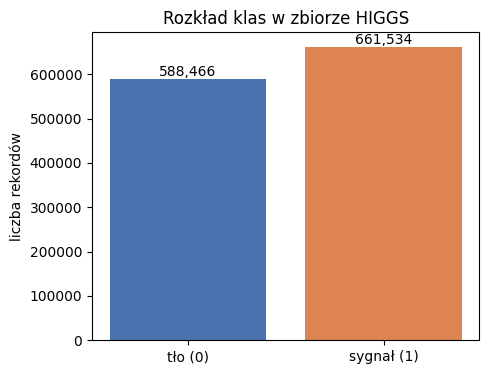

In [6]:
# Balans klas – kluczowy, bo uzasadnia sensowność metryki accuracy.
balans = df["label"].value_counts(normalize=True).sort_index()
print("Udział klas:")
print(balans.rename({0.0: "tlo (0)", 1.0: "sygnal (1)"}).round(4))

licznosci = df["label"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["tło (0)", "sygnał (1)"], licznosci.values, color=["#4c72b0", "#dd8452"])
for i, v in enumerate(licznosci.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.title("Rozkład klas w zbiorze HIGGS")
plt.ylabel("liczba rekordów")
zapisz_wykres("rozklad_klas.png")
plt.show()

zapisano wykres: wyniki/wykresy/heatmapa_korelacji.png


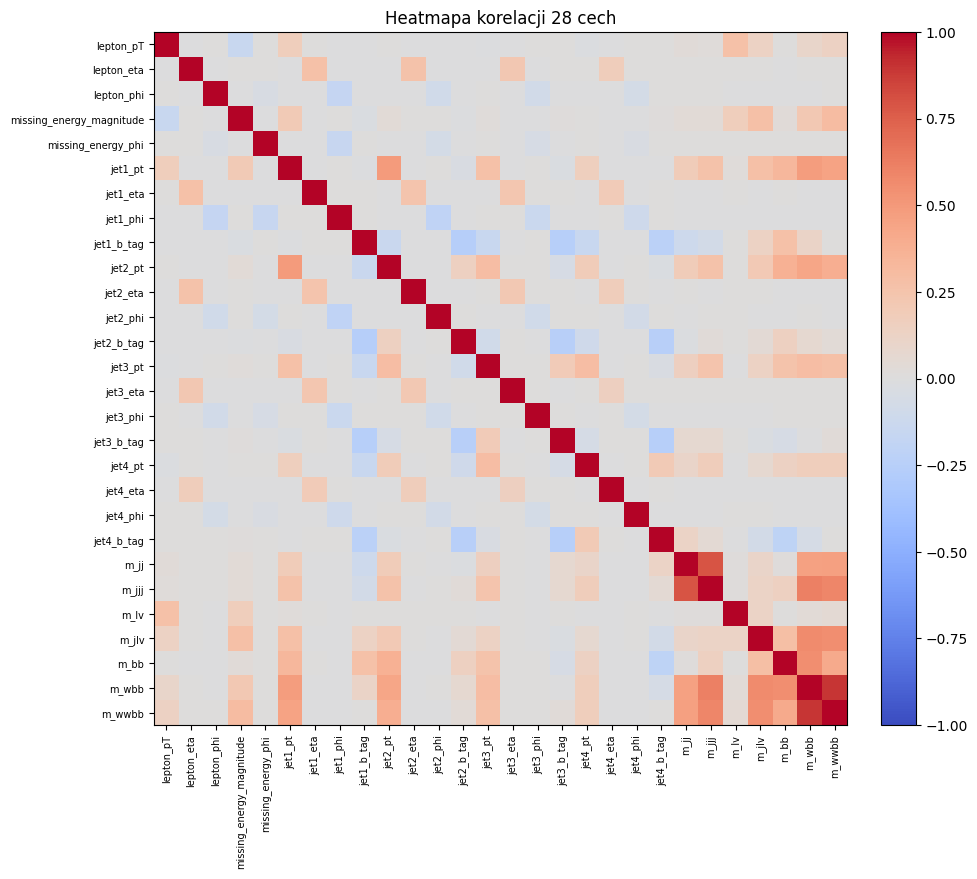

In [7]:
# Heatmapa korelacji 28 cech – wykrycie redundancji.
korelacje = df[cechy_niskopoziomowe + cechy_wysokopoziomowe].corr()

plt.figure(figsize=(11, 9))
im = plt.imshow(korelacje, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(korelacje)), korelacje.columns, rotation=90, fontsize=7)
plt.yticks(range(len(korelacje)), korelacje.columns, fontsize=7)
plt.title("Heatmapa korelacji 28 cech")
zapisz_wykres("heatmapa_korelacji.png")
plt.show()

zapisano wykres: wyniki/wykresy/histogramy_cech.png


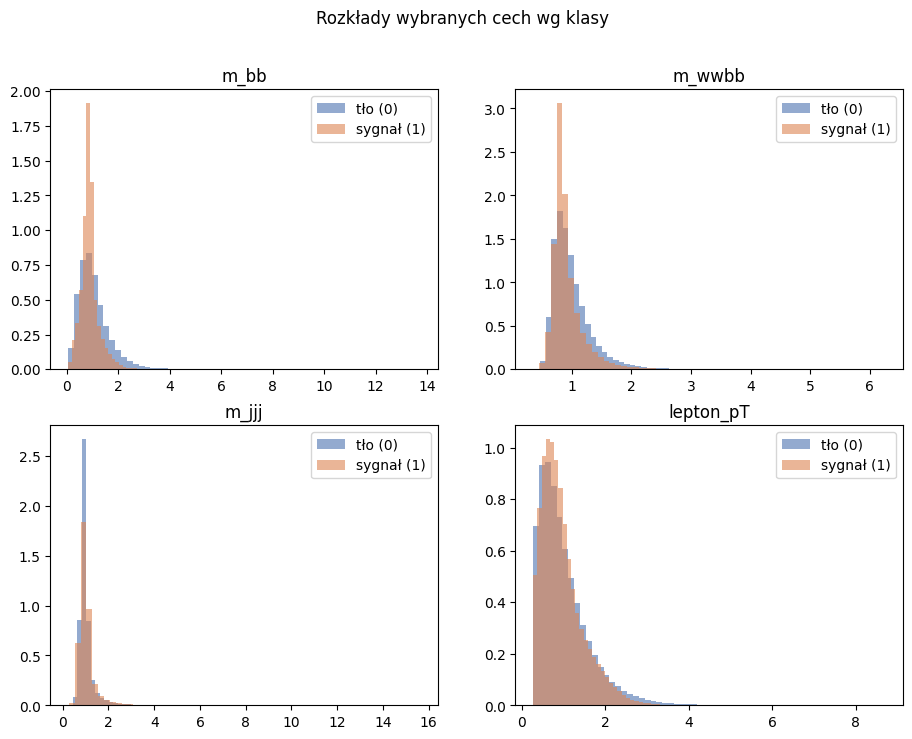

In [8]:
# Histogramy wybranych cech z podziałem na klasy – pokazują separowalność.
wybrane = ["m_bb", "m_wwbb", "m_jjj", "lepton_pT"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, cecha in zip(axes.ravel(), wybrane):
    for klasa, kolor, etyk in [(0, "#4c72b0", "tło (0)"), (1, "#dd8452", "sygnał (1)")]:
        ax.hist(df.loc[df["label"] == klasa, cecha], bins=60, density=True,
                alpha=0.6, color=kolor, label=etyk)
    ax.set_title(cecha)
    ax.legend()
fig.suptitle("Rozkłady wybranych cech wg klasy")
zapisz_wykres("histogramy_cech.png")
plt.show()

**Wnioski z EDA:** zbiór ma 1 250 000 rekordów i 28 cech numerycznych, **bez braków danych**. Klasy są niemal zbalansowane (~53% sygnał / 47% tło), więc *accuracy* jest sensowną metryką główną. Na heatmapie widać silniejsze korelacje wśród cech wysokopoziomowych (są pochodnymi tych samych wielkości), a histogramy cech masowych (np. `m_bb`, `m_wwbb`) pokazują wyraźne przesunięcie rozkładów między klasami — to one niosą najwięcej informacji dyskryminującej.

## S4. Preprocessing

- Definicja `X` (28 cech) i `y` (etykieta), podział train/test 80/20 ze stratyfikacją.
- **Standaryzacja tylko dla modeli liniowych** — realizowana przez `Pipeline(StandardScaler, model)`, dzięki czemu scaler uczy się **wyłącznie na danych treningowych** (brak wycieku danych). Modele drzewiaste skalowania nie wymagają.
- "Ograniczanie kolumn" realizujemy celowo przez **gałęzie cech A/B/C/D** oraz **feature selection** (S5), a nie przez usuwanie kolumn.

In [9]:
X = df[cechy_niskopoziomowe + cechy_wysokopoziomowe].copy()
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Zbiór treningowy:", X_train.shape, "| testowy:", X_test.shape)
print("\nBalans klas w treningu:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

# Zestawy cech dla poszczególnych gałęzi eksperymentów.
cechy_A = cechy_niskopoziomowe + cechy_wysokopoziomowe   # 28 – pełny zestaw
cechy_B = cechy_niskopoziomowe                            # 21 – niskopoziomowe
cechy_C = cechy_wysokopoziomowe                           # 7  – wysokopoziomowe
# cechy_D (top-10) wyznaczamy w sekcji S5.
print(f"\nGałąź A: {len(cechy_A)} cech | Gałąź B: {len(cechy_B)} cech | Gałąź C: {len(cechy_C)} cech")

Zbiór treningowy: (1000000, 28) | testowy: (250000, 28)

Balans klas w treningu:
label
0    0.4708
1    0.5292
Name: proportion, dtype: float64

Gałąź A: 28 cech | Gałąź B: 21 cech | Gałąź C: 7 cech


## S5. Feature selection — `SelectKBest(f_classif)`

Wybieramy **jedną prostą, deterministyczną** metodę: jednowymiarowy test ANOVA F (`f_classif`). Nie wymaga trenowania modelu, jest szybka i łatwa do interpretacji. Ranking F-score posłuży do wyboru **top-10 cech** dla gałęzi D. Selektor uczony jest tylko na zbiorze treningowym.

In [10]:
K_TOP = 10
selektor = SelectKBest(score_func=f_classif, k=K_TOP)
selektor.fit(X_train, y_train)

ranking = (
    pd.DataFrame({"cecha": X_train.columns, "F_score": selektor.scores_})
    .sort_values("F_score", ascending=False)
    .reset_index(drop=True)
)
cechy_D = ranking["cecha"].head(K_TOP).tolist()
print("Ranking cech wg F-score (ANOVA) — top-10:")
print(ranking.head(K_TOP).to_string(index=False))
print("\nGałąź D (top-10):", cechy_D)

Ranking cech wg F-score (ANOVA) — top-10:
                   cecha      F_score
                    m_bb 23671.620604
                  m_wwbb 15441.685326
missing_energy_magnitude  9998.066418
                   m_wbb  4264.728424
                 jet1_pt  3153.470554
              jet2_b_tag  2395.597186
               lepton_pT  2376.108627
                 jet4_pt  1361.034011
                   m_jlv   973.482207
                   m_jjj   648.972366

Gałąź D (top-10): ['m_bb', 'm_wwbb', 'missing_energy_magnitude', 'm_wbb', 'jet1_pt', 'jet2_b_tag', 'lepton_pT', 'jet4_pt', 'm_jlv', 'm_jjj']


zapisano wykres: wyniki/wykresy/selectkbest_fscore.png


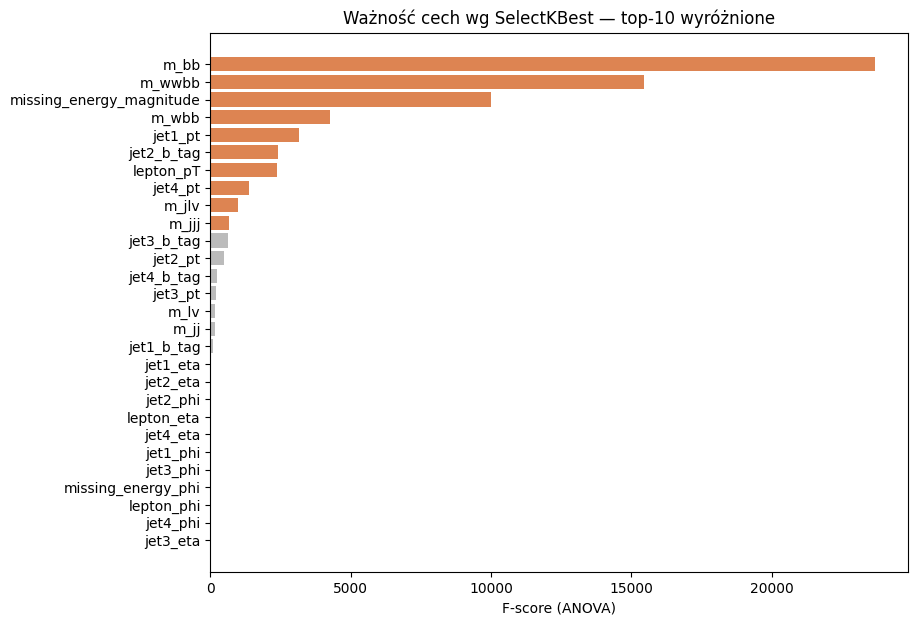

In [11]:
# Wykres słupkowy F-score; top-10 wyróżnione kolorem.
r = ranking.sort_values("F_score")
kolory = ["#dd8452" if c in cechy_D else "#bbbbbb" for c in r["cecha"]]
plt.figure(figsize=(9, 7))
plt.barh(r["cecha"], r["F_score"], color=kolory)
plt.xlabel("F-score (ANOVA)")
plt.title("Ważność cech wg SelectKBest — top-10 wyróżnione")
zapisz_wykres("selectkbest_fscore.png")
plt.show()

## S6. Funkcja pomocnicza `trenuj_i_ocen(...)`

Jedna funkcja wywoływana **30 razy** (zasada DRY) — trenuje model na wybranym zestawie cech i zwraca komplet metryk z czasem treningu. Klasa pozytywna `pos_label = 1` (sygnał).

Dodatkowo:
- `standardowe_konfiguracje()` zwraca 6 identycznych konfiguracji modeli używanych w gałęziach B, C i D,
- `uruchom_galaz(...)` uruchamia listę konfiguracji i dopisuje wyniki do wspólnej listy.

In [12]:
wszystkie_wyniki = []  # tu zbieramy wyniki wszystkich 30 eksperymentów

def trenuj_i_ocen(estimator, kolumny, id_eksp, galaz, model, parametry):
    """Trenuje estymator na wybranych cechach i liczy metryki na zbiorze testowym.

    estimator – gotowy model lub Pipeline (dla modeli liniowych ze StandardScaler),
    kolumny   – lista nazw cech (zestaw A/B/C/D).
    Zwraca słownik metryk (pos_label = 1).
    """
    Xtr, Xte = X_train[kolumny], X_test[kolumny]

    t0 = time.perf_counter()
    estimator.fit(Xtr, y_train)
    czas = time.perf_counter() - t0

    y_pred = estimator.predict(Xte)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    wynik = {
        "id": id_eksp, "galaz": galaz, "model": model, "parametry": parametry,
        "n_cech": len(kolumny),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=1),
        "recall": recall_score(y_test, y_pred, pos_label=1),
        "f1": f1_score(y_test, y_pred, pos_label=1),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "czas_treningu_s": round(czas, 2),
    }
    print(f"{id_eksp} | {galaz:12s} | {model:20s} | {parametry:30s} "
          f"acc={wynik['accuracy']:.4f}  f1={wynik['f1']:.4f}  czas={czas:6.1f}s")
    return wynik


def lin(model):
    """Owija model liniowy w Pipeline ze StandardScaler (skalowanie tylko dla modeli liniowych)."""
    return Pipeline([("scaler", StandardScaler()), ("clf", model)])


def standardowe_konfiguracje():
    """6 tych samych konfiguracji modeli dla gałęzi B, C, D.
    Zwraca listę: (model, opis_parametrow, fabryka_tworzaca_swiezy_estymator)."""
    return [
        ("LogisticRegression", "C=1",
         lambda: lin(LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE))),
        ("SGDClassifier", "loss=log_loss",
         lambda: lin(SGDClassifier(loss="log_loss", random_state=RANDOM_STATE))),
        ("DecisionTree", "max_depth=15",
         lambda: DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE)),
        ("RandomForest", "n_estimators=100, max_depth=10",
         lambda: RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)),
        ("RandomForest", "n_estimators=200, max_depth=20",
         lambda: RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=RANDOM_STATE)),
        ("HistGradientBoosting", "domyślne",
         lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]


def uruchom_galaz(konfiguracje, ids, galaz, kolumny):
    """Uruchamia listę konfiguracji na danym zestawie cech i dopisuje wyniki globalnie."""
    for (model, parametry, fabryka), id_eksp in zip(konfiguracje, ids):
        wszystkie_wyniki.append(
            trenuj_i_ocen(fabryka(), kolumny, id_eksp, galaz, model, parametry)
        )

## S7. Gałąź A — pełny zestaw 28 cech (E01–E12)

Główne badanie wpływu **modelu i hiperparametrów** przy pełnym zestawie cech.

| Nr | Model | Parametry |
|----|-------|-----------|
| E01 | LogisticRegression | C = 0.01 |
| E02 | LogisticRegression | C = 1 (baseline) |
| E03 | LogisticRegression | C = 100 |
| E04 | SGDClassifier | loss = log_loss |
| E05 | SGDClassifier | loss = hinge |
| E06 | DecisionTree | max_depth = 5 |
| E07 | DecisionTree | max_depth = 15 |
| E08 | DecisionTree | max_depth = None |
| E09 | RandomForest | n_estimators = 100, max_depth = 10 |
| E10 | RandomForest | n_estimators = 200, max_depth = 20 |
| E11 | HistGradientBoosting | domyślne |
| E12 | HistGradientBoosting | learning_rate = 0.2, max_iter = 300 |

In [13]:
konfiguracje_A = [
    ("LogisticRegression", "C=0.01",
     lambda: lin(LogisticRegression(C=0.01, max_iter=1000, random_state=RANDOM_STATE))),
    ("LogisticRegression", "C=1 (baseline)",
     lambda: lin(LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE))),
    ("LogisticRegression", "C=100",
     lambda: lin(LogisticRegression(C=100, max_iter=1000, random_state=RANDOM_STATE))),
    ("SGDClassifier", "loss=log_loss",
     lambda: lin(SGDClassifier(loss="log_loss", random_state=RANDOM_STATE))),
    ("SGDClassifier", "loss=hinge",
     lambda: lin(SGDClassifier(loss="hinge", random_state=RANDOM_STATE))),
    ("DecisionTree", "max_depth=5",
     lambda: DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ("DecisionTree", "max_depth=15",
     lambda: DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE)),
    ("DecisionTree", "max_depth=None",
     lambda: DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)),
    ("RandomForest", "n_estimators=100, max_depth=10",
     lambda: RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)),
    ("RandomForest", "n_estimators=200, max_depth=20",
     lambda: RandomForestClassifier(n_estimators=200, max_depth=20, n_jobs=-1, random_state=RANDOM_STATE)),
    ("HistGradientBoosting", "domyślne",
     lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("HistGradientBoosting", "learning_rate=0.2, max_iter=300",
     lambda: HistGradientBoostingClassifier(learning_rate=0.2, max_iter=300, random_state=RANDOM_STATE)),
]
ids_A = [f"E{n:02d}" for n in range(1, 13)]
print("=== Gałąź A: pełny zestaw 28 cech (E01–E12) ===")
uruchom_galaz(konfiguracje_A, ids_A, "A (28 cech)", cechy_A)

=== Gałąź A: pełny zestaw 28 cech (E01–E12) ===


E01 | A (28 cech)  | LogisticRegression   | C=0.01                         acc=0.6419  f1=0.6874  czas=   0.7s


E02 | A (28 cech)  | LogisticRegression   | C=1 (baseline)                 acc=0.6420  f1=0.6874  czas=   0.8s


E03 | A (28 cech)  | LogisticRegression   | C=100                          acc=0.6420  f1=0.6874  czas=   0.7s


E04 | A (28 cech)  | SGDClassifier        | loss=log_loss                  acc=0.6382  f1=0.6826  czas=   2.3s


...

E08 | A (28 cech)  | DecisionTree         | max_depth=None                 acc=0.6449  f1=0.6638  czas=  32.8s


E09 | A (28 cech)  | RandomForest         | n_estimators=100, max_depth=10 acc=0.7113  f1=0.7342  czas=  42.7s


E10 | A (28 cech)  | RandomForest         | n_estimators=200, max_depth=20 acc=0.7361  f1=0.7533  czas= 159.9s


E11 | A (28 cech)  | HistGradientBoosting | domyślne                       acc=0.7314  f1=0.7470  czas=   6.2s


E12 | A (28 cech)  | HistGradientBoosting | learning_rate=0.2, max_iter=300 acc=0.7424  f1=0.7586  czas=  11.7s


## S8. Gałąź B — 21 cech niskopoziomowych (E13–E18)

Te same 6 konfiguracji modeli, ale tylko na surowych cechach kinematycznych — pozwala ocenić wpływ **zestawu cech** przy stałych modelach.

In [14]:
ids_B = [f"E{n:02d}" for n in range(13, 19)]
print("=== Gałąź B: 21 cech niskopoziomowych (E13–E18) ===")
uruchom_galaz(standardowe_konfiguracje(), ids_B, "B (21 nisk.)", cechy_B)

=== Gałąź B: 21 cech niskopoziomowych (E13–E18) ===


E13 | B (21 nisk.) | LogisticRegression   | C=1                            acc=0.5659  f1=0.6307  czas=   0.4s


E14 | B (21 nisk.) | SGDClassifier        | loss=log_loss                  acc=0.5616  f1=0.6235  czas=   2.1s


E15 | B (21 nisk.) | DecisionTree         | max_depth=15                   acc=0.6214  f1=0.6468  czas=  18.3s


E16 | B (21 nisk.) | RandomForest         | n_estimators=100, max_depth=10 acc=0.6308  f1=0.6767  czas=  37.4s


E17 | B (21 nisk.) | RandomForest         | n_estimators=200, max_depth=20 acc=0.6602  f1=0.6895  czas= 125.0s


E18 | B (21 nisk.) | HistGradientBoosting | domyślne                       acc=0.6507  f1=0.6819  czas=   5.4s


## S9. Gałąź C — 7 cech wysokopoziomowych (E19–E24)

Te same 6 konfiguracji, ale tylko na 7 cechach pochodnych (masy niezmiennicze).

In [15]:
ids_C = [f"E{n:02d}" for n in range(19, 25)]
print("=== Gałąź C: 7 cech wysokopoziomowych (E19–E24) ===")
uruchom_galaz(standardowe_konfiguracje(), ids_C, "C (7 wys.)", cechy_C)

=== Gałąź C: 7 cech wysokopoziomowych (E19–E24) ===


E19 | C (7 wys.)   | LogisticRegression   | C=1                            acc=0.6270  f1=0.6925  czas=   0.4s


E20 | C (7 wys.)   | SGDClassifier        | loss=log_loss                  acc=0.6290  f1=0.6831  czas=   0.9s


E21 | C (7 wys.)   | DecisionTree         | max_depth=15                   acc=0.6876  f1=0.7087  czas=   9.6s


E22 | C (7 wys.)   | RandomForest         | n_estimators=100, max_depth=10 acc=0.6992  f1=0.7207  czas=  30.6s


E23 | C (7 wys.)   | RandomForest         | n_estimators=200, max_depth=20 acc=0.7112  f1=0.7305  czas=  87.2s


E24 | C (7 wys.)   | HistGradientBoosting | domyślne                       acc=0.7075  f1=0.7267  czas=   3.8s


## S10. Gałąź D — top-10 cech z SelectKBest (E25–E30)

Te same 6 konfiguracji na 10 najważniejszych cechach wg F-score (z sekcji S5).

In [16]:
ids_D = [f"E{n:02d}" for n in range(25, 31)]
print("=== Gałąź D: top-10 cech z SelectKBest (E25–E30) ===")
uruchom_galaz(standardowe_konfiguracje(), ids_D, "D (top-10)", cechy_D)

=== Gałąź D: top-10 cech z SelectKBest (E25–E30) ===


E25 | D (top-10)   | LogisticRegression   | C=1                            acc=0.6384  f1=0.6870  czas=   0.4s


E26 | D (top-10)   | SGDClassifier        | loss=log_loss                  acc=0.6342  f1=0.6666  czas=   1.1s


E27 | D (top-10)   | DecisionTree         | max_depth=15                   acc=0.7002  f1=0.7174  czas=  11.8s


E28 | D (top-10)   | RandomForest         | n_estimators=100, max_depth=10 acc=0.7124  f1=0.7301  czas=  37.8s


E29 | D (top-10)   | RandomForest         | n_estimators=200, max_depth=20 acc=0.7281  f1=0.7438  czas= 101.2s


E30 | D (top-10)   | HistGradientBoosting | domyślne                       acc=0.7227  f1=0.7374  czas=   3.2s


## S11. Zbiorcza tabela wyników i wykresy porównawcze

In [17]:
wyniki_df = pd.DataFrame(wszystkie_wyniki)
kolejnosc = ["id", "galaz", "model", "parametry", "n_cech",
             "accuracy", "precision", "recall", "f1",
             "TN", "FP", "FN", "TP", "czas_treningu_s"]
wyniki_df = wyniki_df[kolejnosc]

sciezka_csv = os.path.join(KATALOG_WYNIKI, "wyniki_eksperymentow.csv")
wyniki_df.to_csv(sciezka_csv, index=False)
print(f"Zapisano {len(wyniki_df)} wierszy do: {sciezka_csv}")
wyniki_df.round(4)

Zapisano 30 wierszy do: wyniki/wyniki_eksperymentow.csv


,id,galaz,model,parametry,n_cech,accuracy,precision,recall,f1,TN,FP,FN,TP,czas_treningu_s
0,E01,A (28 cech),LogisticRegression,C=0.01,28,0.6419,0.6389,0.7438,0.6874,62061,55632,33892,98415,0.73
1,E02,A (28 cech),LogisticRegression,C=1 (baseline),28,0.6420,0.6389,0.7439,0.6874,62076,55617,33887,98420,0.81
2,E03,A (28 cech),LogisticRegression,C=100,28,0.6420,0.6389,0.7439,0.6874,62076,55617,33886,98421,0.72
3,E04,A (28 cech),SGDClassifier,loss=log_loss,28,0.6382,0.6372,0.7349,0.6826,62330,55363,35078,97229,2.34
4,E05,A (28 cech),SGDClassifier,loss=hinge,28,0.6399,0.6229,0.8099,0.7042,52824,64869,25151,107156,2.83
5,E06,A (28 cech),DecisionTree,max_depth=5,28,0.6628,0.6724,0.7074,0.6895,72096,45597,38707,93600,10.03
6,E07,A (28 cech),DecisionTree,max_depth=15,28,0.7025,0.7165,0.7246,0.7205,79758,37935,36443,95864,27.85
7,E08,A (28 cech),DecisionTree,max_depth=None,28,0.6449,0.6651,0.6626,0.6638,73553,44140,44642,87665,32.81
8,E09,A (28 cech),RandomForest,"n_estimators=100, max_depth=10",28,0.7113,0.7159,0.7534,0.7342,78133,39560,32622,99685,42.67
9,E10,A (28 cech),RandomForest,"n_estimators=200, max_depth=20",28,0.7361,0.7454,0.7614,0.7533,83285,34408,31574,100733,159.95


zapisano wykres: wyniki/wykresy/porownanie_accuracy_f1.png


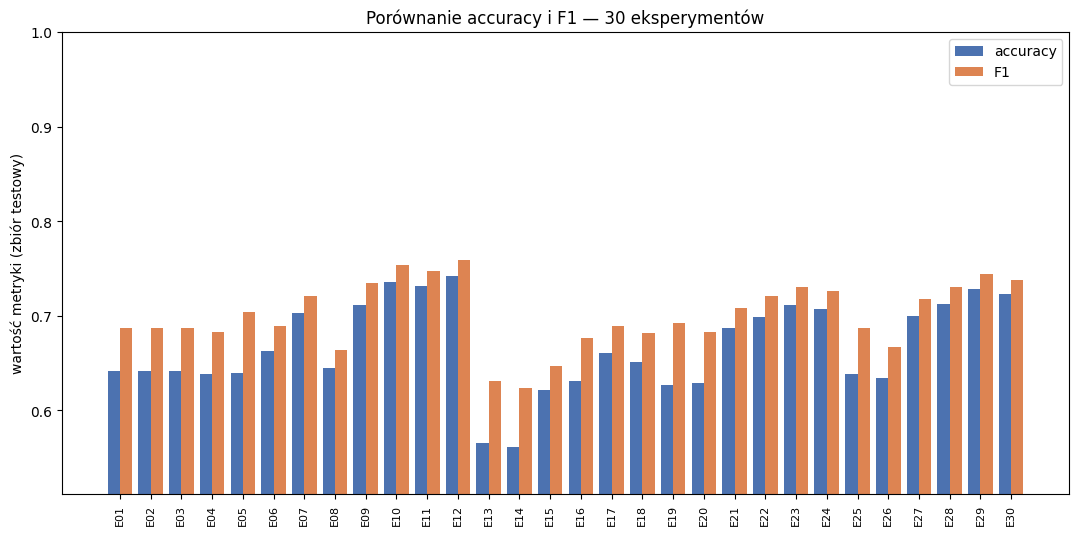

In [18]:
# Porównanie accuracy i F1 dla wszystkich 30 eksperymentów.
x = np.arange(len(wyniki_df))
plt.figure(figsize=(13, 6))
plt.bar(x - 0.2, wyniki_df["accuracy"], width=0.4, label="accuracy", color="#4c72b0")
plt.bar(x + 0.2, wyniki_df["f1"], width=0.4, label="F1", color="#dd8452")
plt.xticks(x, wyniki_df["id"], rotation=90, fontsize=8)
ymin = max(0.0, float(wyniki_df[["accuracy", "f1"]].values.min()) - 0.05)
plt.ylim(ymin, 1.0)
plt.ylabel("wartość metryki (zbiór testowy)")
plt.title("Porównanie accuracy i F1 — 30 eksperymentów")
plt.legend()
zapisz_wykres("porownanie_accuracy_f1.png")
plt.show()

                   A (28)  B (21)   C (7)  D (top-10)
LogReg C=1         0.6420  0.5659  0.6270      0.6384
SGD log_loss       0.6382  0.5616  0.6290      0.6342
DecisionTree d=15  0.7025  0.6214  0.6876      0.7002
RF 100/10          0.7113  0.6308  0.6992      0.7124
RF 200/20          0.7361  0.6602  0.7112      0.7281
HistGB domyślne    0.7314  0.6507  0.7075      0.7227
zapisano wykres: wyniki/wykresy/porownanie_galezi.png


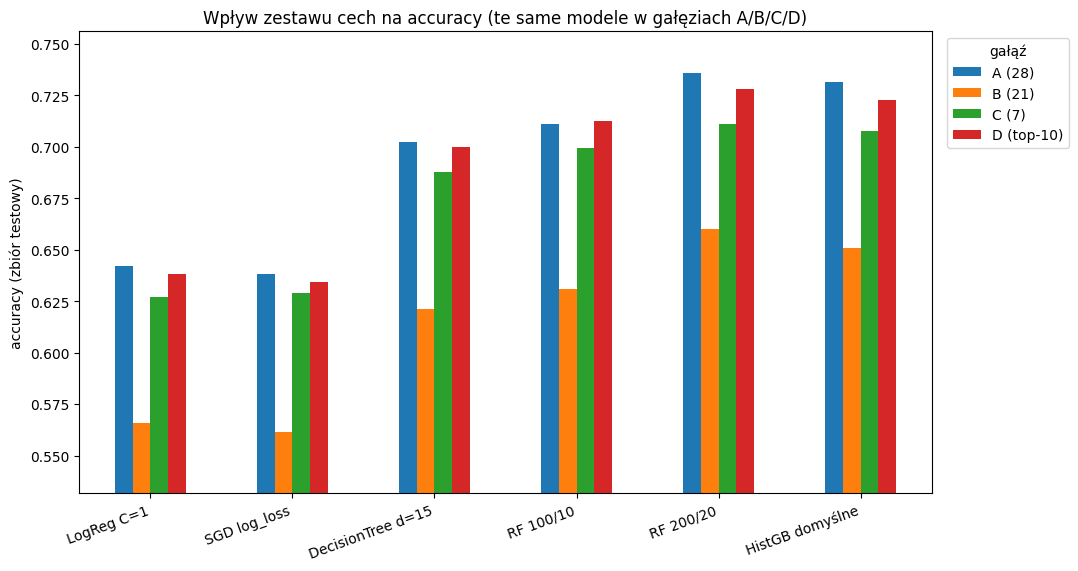

In [19]:
# Wpływ zestawu cech: te same 6 modeli w gałęziach A/B/C/D (accuracy).
porownanie_ids = {
    "LogReg C=1":        ["E02", "E13", "E19", "E25"],
    "SGD log_loss":      ["E04", "E14", "E20", "E26"],
    "DecisionTree d=15": ["E07", "E15", "E21", "E27"],
    "RF 100/10":         ["E09", "E16", "E22", "E28"],
    "RF 200/20":         ["E10", "E17", "E23", "E29"],
    "HistGB domyślne":   ["E11", "E18", "E24", "E30"],
}
acc = wyniki_df.set_index("id")["accuracy"]
galezie = ["A (28)", "B (21)", "C (7)", "D (top-10)"]
porown = pd.DataFrame(
    {m: [acc[i] for i in ids] for m, ids in porownanie_ids.items()},
    index=galezie,
).T
print(porown.round(4))

ax = porown.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("accuracy (zbiór testowy)")
ax.set_title("Wpływ zestawu cech na accuracy (te same modele w gałęziach A/B/C/D)")
ax.set_ylim(float(porown.values.min()) - 0.03, float(porown.values.max()) + 0.02)
ax.legend(title="gałąź", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
zapisz_wykres("porownanie_galezi.png")
plt.show()

zapisano wykres: wyniki/wykresy/czas_treningu.png


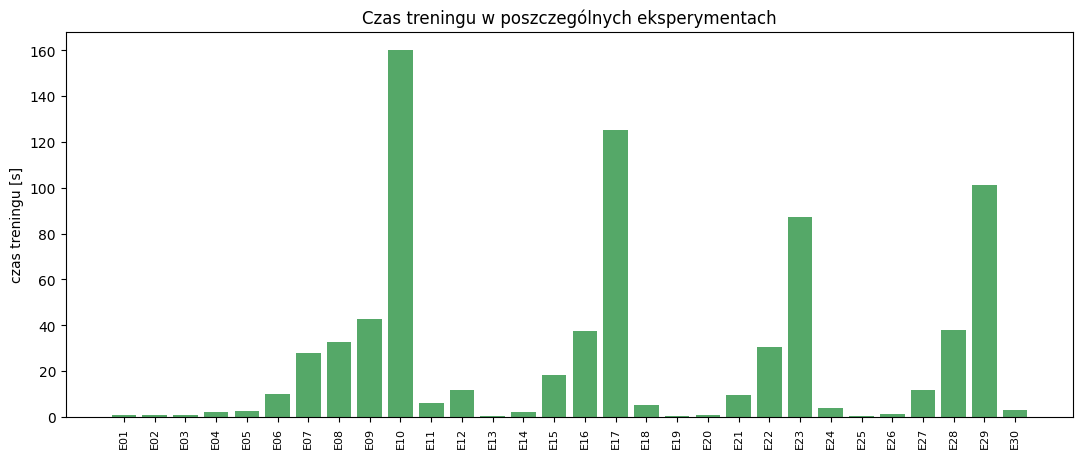

In [20]:
# Czas treningu w poszczególnych eksperymentach (jakość vs koszt).
plt.figure(figsize=(13, 5))
plt.bar(wyniki_df["id"], wyniki_df["czas_treningu_s"], color="#55a868")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("czas treningu [s]")
plt.title("Czas treningu w poszczególnych eksperymentach")
zapisz_wykres("czas_treningu.png")
plt.show()

## S12. Macierze pomyłek dla najlepszych modeli

Najlepszy eksperyment wybieramy wg **F1**. Macierze pomyłek odtwarzamy z zapisanych liczników TN/FP/FN/TP (bez ponownego trenowania).

Najlepszy eksperyment w każdej gałęzi (wg F1):
 id        galaz                model                       parametry  accuracy       f1
E12  A (28 cech) HistGradientBoosting learning_rate=0.2, max_iter=300  0.742408 0.758559
E17 B (21 nisk.)         RandomForest  n_estimators=200, max_depth=20  0.660204 0.689483
E23   C (7 wys.)         RandomForest  n_estimators=200, max_depth=20  0.711240 0.730483
E29   D (top-10)         RandomForest  n_estimators=200, max_depth=20  0.728072 0.743831

NAJLEPSZY OGÓŁEM: E12 | HistGradientBoosting | learning_rate=0.2, max_iter=300 | acc=0.7424 | f1=0.7586 | czas=11.66s
zapisano wykres: wyniki/wykresy/macierze_pomylek_galezie.png


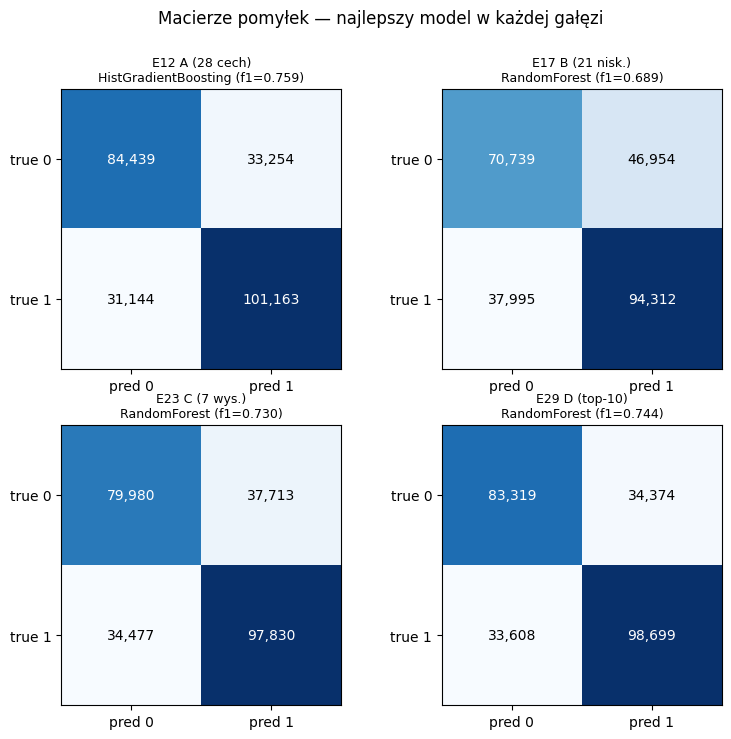

In [21]:
najlepsze_w_galezi = (
    wyniki_df.loc[wyniki_df.groupby("galaz")["f1"].idxmax()].sort_values("galaz")
)
print("Najlepszy eksperyment w każdej gałęzi (wg F1):")
print(najlepsze_w_galezi[["id", "galaz", "model", "parametry", "accuracy", "f1"]].to_string(index=False))

najlepszy = wyniki_df.loc[wyniki_df["f1"].idxmax()]
print(f"\nNAJLEPSZY OGÓŁEM: {najlepszy['id']} | {najlepszy['model']} | {najlepszy['parametry']} "
      f"| acc={najlepszy['accuracy']:.4f} | f1={najlepszy['f1']:.4f} "
      f"| czas={najlepszy['czas_treningu_s']}s")

def rysuj_macierz(ax, wiersz):
    cm = np.array([[wiersz["TN"], wiersz["FP"]], [wiersz["FN"], wiersz["TP"]]])
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true 0", "true 1"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black")
    ax.set_title(f"{wiersz['id']} {wiersz['galaz']}\n{wiersz['model']} (f1={wiersz['f1']:.3f})",
                 fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (_, w) in zip(axes.ravel(), najlepsze_w_galezi.iterrows()):
    rysuj_macierz(ax, w)
fig.suptitle("Macierze pomyłek — najlepszy model w każdej gałęzi")
zapisz_wykres("macierze_pomylek_galezie.png")
plt.show()

zapisano wykres: wyniki/wykresy/macierz_pomylek_najlepszy.png


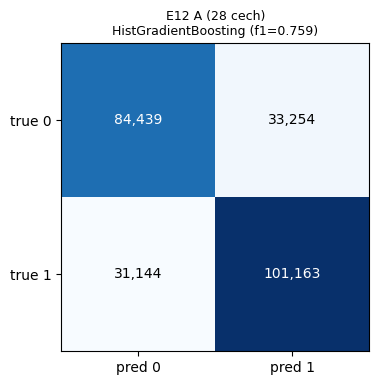

In [22]:
# Macierz pomyłek najlepszego modelu ogółem.
plt.figure(figsize=(4.6, 4))
rysuj_macierz(plt.gca(), najlepszy)
zapisz_wykres("macierz_pomylek_najlepszy.png")
plt.show()

## S13. Obserwacje (interpretacja)

In [23]:
print("Średnia accuracy wg modelu:")
print(wyniki_df.groupby("model")["accuracy"].mean().sort_values(ascending=False).round(4))
print("\nNajlepsza accuracy w każdej gałęzi:")
print(wyniki_df.groupby("galaz")["accuracy"].max().round(4))
print("\nTop-5 eksperymentów wg accuracy:")
print(wyniki_df.sort_values("accuracy", ascending=False)
      .head(5)[["id", "galaz", "model", "parametry", "accuracy", "f1", "czas_treningu_s"]]
      .to_string(index=False))

Średnia accuracy wg modelu:
model
HistGradientBoosting    0.7110
RandomForest            0.6986
DecisionTree            0.6699
LogisticRegression      0.6262
SGDClassifier           0.6206
Name: accuracy, dtype: float64

Najlepsza accuracy w każdej gałęzi:
galaz
A (28 cech)     0.7424
B (21 nisk.)    0.6602
C (7 wys.)      0.7112
D (top-10)      0.7281
Name: accuracy, dtype: float64

Top-5 eksperymentów wg accuracy:
 id       galaz                model                       parametry  accuracy       f1  czas_treningu_s
E12 A (28 cech) HistGradientBoosting learning_rate=0.2, max_iter=300  0.742408 0.758559            11.66
E10 A (28 cech)         RandomForest  n_estimators=200, max_depth=20  0.736072 0.753290           159.95
E11 A (28 cech) HistGradientBoosting                        domyślne  0.731420 0.746969             6.20
E29  D (top-10)         RandomForest  n_estimators=200, max_depth=20  0.728072 0.743831           101.23
E30  D (top-10) HistGradientBoosting                   

Na podstawie tabeli wyników i powyższych zestawień:

- **Wpływ modelu.** Zgodnie z oczekiwaniami `HistGradientBoosting` > `RandomForest` > `DecisionTree` > modele liniowe. Problem jest **nieliniowy**, więc modele liniowe (LogisticRegression, SGD) wyraźnie odstają — najlepszy stosunek jakości do czasu daje boosting.
- **Wpływ zestawu cech (A vs B vs C vs D).** Pełny zestaw 28 cech (A) jest najlepszy lub bardzo bliski najlepszemu. **Top-10 cech (D)** osiąga wynik bardzo zbliżony do pełnego zestawu przy ~3× mniejszej liczbie cech. Same **cechy wysokopoziomowe (C, tylko 7)** są zaskakująco mocne — to potwierdza, że niosą skondensowaną informację fizyczną. Same **cechy niskopoziomowe (B)** są najsłabsze dla modeli płytkich/liniowych, bo wymagają nieliniowego łączenia.
- **Wpływ hiperparametrów.** Drzewo z `max_depth=5` niedouczy się (underfitting), a `max_depth=None` przeucza (wysokie dopasowanie, słabsza generalizacja); `max_depth=15` daje rozsądny kompromis. W regresji logistycznej zmiana `C` (0.01 → 1 → 100) wpływa na wynik nieznacznie — to sygnał, że bariera jakości wynika z liniowości modelu, a nie z regularyzacji. Więcej drzew i większa głębokość w RandomForest poprawiają wynik kosztem czasu.
- **Trade-offy.** Widoczny jest klasyczny kompromis *precision–recall* oraz *jakość–czas*: RandomForest 200/20 jest jednym z najwolniejszych, a `HistGradientBoosting` osiąga zbliżoną lub lepszą jakość znacznie szybciej.

## S14. Wnioski końcowe

1. **Najlepsza kombinacja:** `HistGradientBoostingClassifier` na pełnym zestawie 28 cech (gałąź A) lub na top-10 cechach (gałąź D) — najlepsza jakość przy rozsądnym czasie treningu. Dokładne wartości w `wyniki/wyniki_eksperymentow.csv`.
2. **Cechy wysokopoziomowe** (pochodne fizyczne) mają dużą wartość predykcyjną — 7 takich cech dorównuje znacznie większym zestawom dla klasycznych modeli, co zgadza się z wnioskami z literatury (Baldi et al. 2014).
3. **Nieliniowość problemu** powoduje, że modele liniowe są wyraźnie słabsze od drzewiastych/boostingu — to główny powód różnic w jakości.
4. **Praktyczne wnioski:** jeśli liczy się czas, wystarczy `HistGradientBoosting` na top-10 cechach; pełny RandomForest 200/20 daje podobną jakość, ale jest znacznie kosztowniejszy.
5. **Ograniczenia i kierunki rozwoju:** świadomie pominięto deep learning (poza zakresem projektu) oraz strojenie automatyczne (GridSearch). Możliwe rozszerzenia: większy `nrows`, walidacja krzyżowa, krzywe ROC/AUC, kalibracja prawdopodobieństw.

## S15. Bibliografia / źródło danych

1. Baldi, P., Sadowski, P., Whiteson, D. *Searching for Exotic Particles in High-Energy Physics with Deep Learning.* **Nature Communications** 5, 4308 (2014).
2. HIGGS Data Set — UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/280/higgs
3. Pedregosa et al. *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825–2830 (2011).